# Spotify Lab v3: Simple Vector Recommendations

**Name(s):**

You are a new data engineer at Spotify. When a listener asks for songs with similar content, we want to search a library of songs and return useful recommendations.

In this lab, every song is represented as a vector of lyric word counts. If the word "love" appears 12 times in a song, then the song has coordinate $x_{love}=12$ for that word. Songs with similar word-count patterns should have vectors that look similar.

The main files are:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the 800 word columns used in the vectors
- `./data/top_40_songs_by_genre.csv`: 40 popular songs from each genre, used as a benchmark

The genre labels are useful for evaluation, but they are not perfect ground truth. Some songs cross genres, some labels are debatable, and real recommendation systems would also use audio features, listener behavior, and human judgments.

The main idea of the lab:

**Dot product rewards shared word-count mass. Cosine similarity corrects for vector length. TF-IDF changes which words matter.**

## What You Will Submit

Complete the notebook and answer the yellow prompts in your own words. Your answers should focus on what each scoring rule rewards and whether the recommendations seem useful.

At the end, write a short 2-4 paragraph report. State which method you would recommend for this lyric-only prototype, use examples from the rankings, and explain one important limitation of using lyric word counts alone.

## Setup

We will use only `pandas`, `numpy`, and `seaborn`.

//Overall goal: find if these songs are similar or different so that you can recommend
//using genre as ground truth: if the genre they like was pop, the recommender should be pop --> want to hit the genre correctly

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

songs = pd.read_csv("./data/song_vectors.csv.gz")
vocab = pd.read_csv("./data/vocabulary.csv")
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist()
meta_cols = [col for col in songs.columns if col not in word_cols]

X = songs[word_cols].to_numpy(dtype=float)

print("songs:", songs.shape)
print("word-count matrix:", X.shape)
print("top-40 benchmark:", top_40.shape)

songs: (8000, 816)
word-count matrix: (8000, 800)
top-40 benchmark: (560, 6)


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Inspect One Song Vector

Each row of `X` is one song vector. We will start with a single query song so the scoring rules are easier to see.

In [3]:
query_row = 0
query_track_id = songs.loc[query_row, "track_id"]
query = X[query_row]

songs.loc[[query_row], ["artist_name", "song_title", "genre", "n_words", "nnz_words"]]

,artist_name,song_title,genre,n_words,nnz_words
0,Gary Moore,What Are We Here For,blues,218,80


In [4]:
word_counts = pd.DataFrame({
    "word": word_cols,
    "count": query.astype(int),
})

word_counts.query("count > 0").sort_values("count", ascending=False).head(15)

,word,count
748,we,27
31,are,10
245,for,9
475,of,7
336,it,6
753,what,6
306,here,6
295,have,6
489,our,5
676,through,5


<div class="alert alert-block alert-warning">

What are the most common words in the query song? Do they look like words that would be useful for recommending similar songs? Why or why not?

</div>

These are like transition words, no big theme words, not very specific words

No we smash the vocab from this song, then smash with other songs, and see if there is a hit, Essentially what RAG: retreived augumented generation is and what AI is 

## Part 2: Dot Product

The dot product is:

$$
x \cdot y = \sum_j x_j y_j
$$

It gets large when two songs use many of the same words many times. That can be useful, but it can also reward long or repetitive songs.

In [5]:
def top_matches(scores, query_track_id, k=10, query_artist_id=None):
    results = songs[meta_cols].copy()
    results["score"] = scores

    results = results[results["track_id"] != query_track_id]
    if query_artist_id is not None:
        results = results[results["artist_id"] != query_artist_id]

    return results.sort_values("score", ascending=False).head(k)

In [6]:
dot_scores = X @ query
dot_matches = top_matches(dot_scores, query_track_id, k=10)

dot_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
1582,The Prodigy,We Gonna Rock,electronic,312,2136.0
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,2115.0
5601,Bowling For Soup,Here We Go,punk,374,1939.0
1930,Ladyhawke,Crazy World,electronic,340,1680.0
6997,Ziggy Marley And The Melody Makers,We Propose,reggae,297,1656.0
3053,The Streets,Weak Become Heroes,hip hop,754,1654.0
2971,Black Eyed Peas,Communication,hip hop,592,1615.0
2874,Hollywood Undead,Undead,hip hop,831,1476.0
5840,Rise Against,Survive,punk,324,1383.0
3085,Binary Star,Indy 500,hip hop,977,1331.0


[Text(0.5, 1.0, 'Dot product top matches'),
 Text(0.5, 0, 'dot product'),
 Text(0, 0.5, '')]

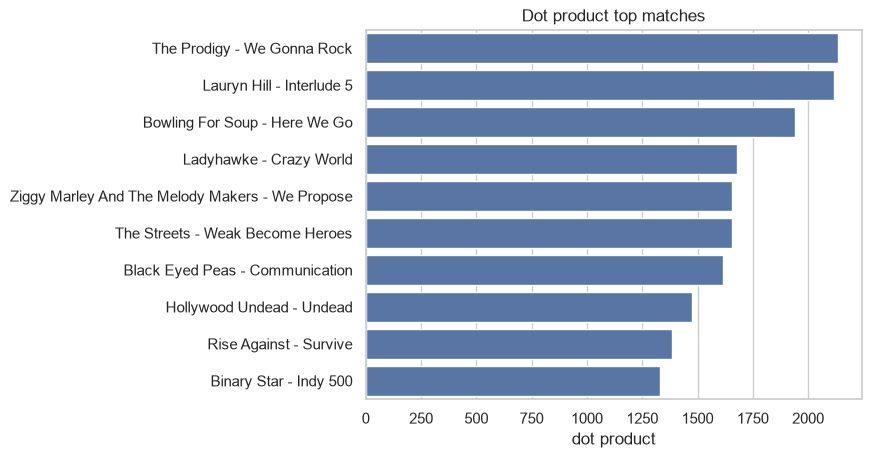

In [7]:
plot_data = dot_matches.copy()
plot_data["song"] = plot_data["artist_name"] + " - " + plot_data["song_title"]

ax = sns.barplot(data=plot_data, y="song", x="score")
ax.set(title="Dot product top matches", xlabel="dot product", ylabel="")

// we see that we have a high dot product score, but we still do not have the correct genre of song. This is because only lyrics does not indicate genre at all.
// to handle, engram: we analyze words together ? Need to look it up
// if I wanted to make a song that was recommended a lot, I would make a song that has the most popular words in it and make it long 
// --> but this problem where it is a really long song, and lots of words, we would NORMALIZE

<div class="alert alert-block alert-warning">

Look at the dot-product matches. Do they seem similar to the query song, or does the score seem to reward song size/repetition? Use at least one specific song from the table in your answer.

</div>

## Part 3: Cosine Similarity

Cosine similarity divides the dot product by the lengths of the two vectors:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

This compares the direction of the word-count profiles. A long song does not automatically win just because it has more words.

// this adjusts for the length and number of words in the song

In [8]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    denominators = np.linalg.norm(matrix, axis=1) * np.linalg.norm(query_vector)

    return np.divide(
        numerators,
        denominators,
        out=np.zeros(len(numerators)),
        where=denominators != 0,
    )

// now ranked values are between -1 and 1
// NOTE: no negative scores because cannot have an opposite word in this sense, also, these are just counts, so they will be positive
// this is unique to instances: so here, either similar or not related, but never opposite

In [9]:
cos_scores = cosine_scores(X, query)
cos_matches = top_matches(cos_scores, query_track_id, k=10)

cos_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
6997,Ziggy Marley And The Melody Makers,We Propose,reggae,297,0.761523
4677,Modern Life Is War,Destination: Death or Better Days,metal,204,0.755322
4933,EDGUY,Superheroes,metal,191,0.735159
4489,Raised Fist,Soldiers Of Today,metal,222,0.707435
4521,Lifetime,Daneurysm,metal,68,0.703254
4550,Tourniquet,Convoluted Absolutes,metal,189,0.696703
5831,Street Dogs,Free,punk,291,0.696275
4896,Arsonists Get All The Girls,Tourtasia,metal,195,0.692076
5184,Thompson Twins,We Are Detective,pop,172,0.689013
5921,Dead Kennedys,Goons of Hazzard,punk,196,0.687867


[Text(0.5, 1.0, 'Cosine similarity top matches'),
 Text(0.5, 0, 'cosine similarity'),
 Text(0, 0.5, '')]

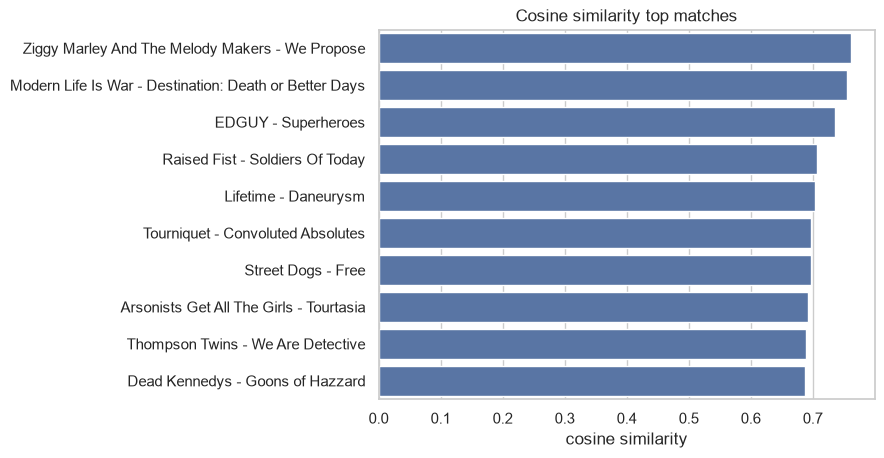

In [10]:
plot_data = cos_matches.copy()
plot_data["song"] = plot_data["artist_name"] + " - " + plot_data["song_title"]

ax = sns.barplot(data=plot_data, y="song", x="score")
ax.set(title="Cosine similarity top matches", xlabel="cosine similarity", ylabel="")

<div class="alert alert-block alert-warning">

Compare the dot-product matches to the cosine matches. Which method looks more like a similar-song engine? Which method looks more like it is rewarding raw word-count mass?

</div>

## Part 4: TF-IDF

Some words appear in many songs. Those words can dominate similarity scores even if they do not tell us much about the song.

TF-IDF changes the word-count matrix in two steps:

1. **Term frequency:** `np.log1p(X)` makes each additional repeated use of a word count less than the previous one. This reduces the marginal effect of repetition within a song.
2. **Inverse document frequency:** words that appear in many songs get smaller weights, and words that appear in fewer songs get larger weights.

Then we use the transformed matrix for recommendations.

In [11]:
TF = np.log1p(X)

document_frequency = (X > 0).sum(axis=0)
IDF = np.log(len(songs) / document_frequency)

TFIDF = TF * IDF

idf_table = pd.DataFrame({
    "word": word_cols,
    "document_frequency": document_frequency,
    "idf": IDF,
})

In [12]:
idf_table.sort_values("idf").head(10)

,word,document_frequency,idf
324,i,5966,0.293365
22,and,5960,0.294371
795,you,5671,0.344076
409,me,5420,0.389346
331,in,5345,0.403280
334,is,5191,0.432515
336,it,5045,0.461044
466,not,4961,0.477834
475,of,4785,0.513956
662,that,4597,0.554038


In [13]:
idf_table.sort_values("idf", ascending=False).head(10)

,word,document_frequency,idf
176,doo,26,5.729100
258,funk,48,5.115996
726,ven,56,4.961845
327,ihr,59,4.909659
770,wir,60,4.892852
201,er,63,4.844062
711,u,66,4.797542
162,dich,68,4.767689
596,sie,78,4.630488
208,eu,81,4.592748


<div class="alert alert-block alert-warning">

What do you notice about the lowest-IDF words and highest-IDF words? Why might this matter for a recommendation system?

</div>

In [14]:
query_tfidf = TFIDF[query_row]

tfidf_dot_scores = TFIDF @ query_tfidf
tfidf_dot_matches = top_matches(tfidf_dot_scores, query_track_id, k=10)

tfidf_dot_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,266.908244
2659,Eminem,8 Mile,hip hop,1141,192.153763
3252,Kurt Elling,Resolution,jazz,605,172.069225
4419,Savatage,The Hourglass,metal,889,169.770168
2691,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,hip hop,1746,163.961655
4547,Pain of Salvation,Kingdom of Loss,metal,498,154.080568
6688,Prince,I Love U In Me ( LP Version),r&b/soul,680,150.685461
4654,Set Your Goals,our ethos: a legacy to pass on,metal,418,149.919458
2991,Binary Star,Honest Expression,hip hop,933,146.504872
3161,Murs,The Dance,hip hop,913,141.616639


In [15]:
tfidf_cos_scores = cosine_scores(TFIDF, query_tfidf)
tfidf_cos_matches = top_matches(tfidf_cos_scores, query_track_id, k=10)

tfidf_cos_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
4654,Set Your Goals,our ethos: a legacy to pass on,metal,418,0.327636
4547,Pain of Salvation,Kingdom of Loss,metal,498,0.311372
1094,Blue Rodeo,Love And Understanding,country,211,0.294766
3252,Kurt Elling,Resolution,jazz,605,0.288733
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,0.288405
4777,Soulfly,One Nation (Album Version),metal,278,0.286295
2739,Hieroglyphics,You Never Knew,hip hop,439,0.286245
6161,Michelle Williams,The Greatest,r&b/soul,301,0.285134
4945,Frantic Bleep,Cone,metal,42,0.283387
1991,Enigma,Out From The Deep,electronic,123,0.278396


<div class="alert alert-block alert-warning">

Compare raw dot product, raw cosine, TF-IDF dot product, and TF-IDF cosine. Which recommendation list seems best for this query song? Give one specific example.

</div>

## Part 5: Benchmark with Genre

Evaluate all four methods on the Top-40 songs.

For each query song, we will:

1. score every possible match,
2. remove the query song itself,
3. remove songs by the same artist,
4. keep the top two matches,
5. record whether each match has the same genre as the query.

The final score is **precision@2**: the share of recommendation slots that match the query genre.

<div class="alert alert-block alert-warning">

Which method has the best precision@2? Does that agree with your judgment from the single-query examples, or does the benchmark change your view?

</div>

## Part 6: Test an Adjustment

A recommendation system is a design choice. Investigate your previous results, think of a promising change to make in the system, and compare it to the pevious methods. Did the adjustment improve results? (It's fine if it didn't.)

could do: engrams and change the way corpus is built, maybe like phrases
- sentiment analysis, would need to find how to do it in python, check out later?, vader?
- take out words that don't have meaning or are not helpful
- maybe instruments?

## Final Report

Write a short report on your results in a document file:

1. Which method would you recommend for this lyric-only prototype?
2. What evidence from the tables or precision@2 scores supports your choice?
3. Give at least two concrete song examples from the recommendations.
4. What is one important limitation of lyric word counts alone? What other data would be helpful, and how would you use it?